Z statistic = -1.7678

TWO-TAILED TEST  (H1: mu != 1000)
  Critical values = ±1.960,  p-value = 0.0771
  Decision: Fail to reject H0

LEFT-TAILED TEST (H1: mu < 1000)
  Critical value = -1.645,  p-value = 0.0385
  Decision: Reject H0

RIGHT-TAILED TEST (H1: mu > 1000)
  Critical value = 1.645, p-value = 0.9615
  Decision: Fail to reject H0


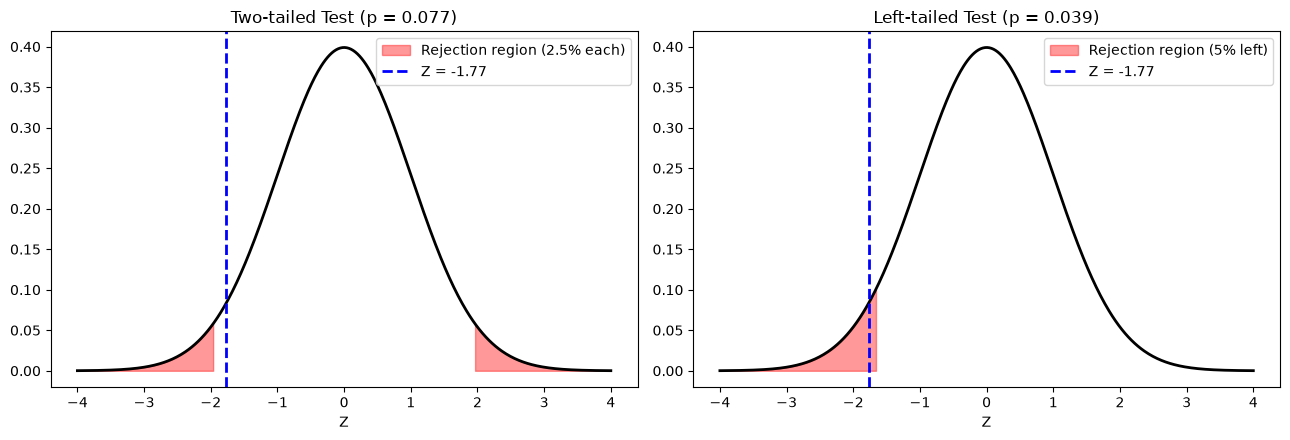

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Given summary data
mu0 = 1000      # claimed mean life (hours)
sigma = 100     # population SD
n = 50
x_bar = 975
alpha = 0.05

# Step 2: Z statistic (same for both tests)
z = (x_bar - mu0) / (sigma / np.sqrt(n))

print(f"Z statistic = {z:.4f}\n")

# Step 3: Two-tailed test
z_crit_two = stats.norm.ppf(1 - alpha / 2)
p_two = 2 * (1 - stats.norm.cdf(abs(z)))

print("TWO-TAILED TEST  (H1: mu != 1000)")
print(f"  Critical values = ±{z_crit_two:.3f},  p-value = {p_two:.4f}")
print(
    "  Decision:",
    "Reject H0" if p_two < alpha else "Fail to reject H0"
)

# Step 4: Left-tailed test
z_crit_left = stats.norm.ppf(alpha)
p_left = stats.norm.cdf(z)

print("\nLEFT-TAILED TEST (H1: mu < 1000)")
print(f"  Critical value = {z_crit_left:.3f},  p-value = {p_left:.4f}")
print(
    "  Decision:",
    "Reject H0" if p_left < alpha else "Fail to reject H0"
)

# Step 5: Right-tailed test (for comparison only)
p_right = 1 - stats.norm.cdf(z)

print("\nRIGHT-TAILED TEST (H1: mu > 1000)")
print(
    f"  Critical value = {stats.norm.ppf(1 - alpha):.3f}, "
    f"p-value = {p_right:.4f}"
)
print(
    "  Decision:",
    "Reject H0" if p_right < alpha else "Fail to reject H0"
)

# Step 6: Graph - two-tailed vs left-tailed rejection regions
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Two-tailed graph
ax[0].plot(x, y, 'k', lw=2)

ax[0].fill_between(
    x,
    y,
    where=(x <= -z_crit_two),
    color='red',
    alpha=0.4,
    label='Rejection region (2.5% each)'
)

ax[0].fill_between(
    x,
    y,
    where=(x >= z_crit_two),
    color='red',
    alpha=0.4
)

ax[0].axvline(
    z,
    color='blue',
    linestyle='--',
    lw=2,
    label=f'Z = {z:.2f}'
)

ax[0].set_title(f'Two-tailed Test (p = {p_two:.3f})')
ax[0].set_xlabel('Z')
ax[0].legend(loc='upper right')

# Left-tailed graph
ax[1].plot(x, y, 'k', lw=2)

ax[1].fill_between(
    x,
    y,
    where=(x <= z_crit_left),
    color='red',
    alpha=0.4,
    label='Rejection region (5% left)'
)

ax[1].axvline(
    z,
    color='blue',
    linestyle='--',
    lw=2,
    label=f'Z = {z:.2f}'
)

ax[1].set_title(f'Left-tailed Test (p = {p_left:.3f})')
ax[1].set_xlabel('Z')
ax[1].legend()

plt.tight_layout()
plt.show()